In [2]:
import numpy as np
import matplotlib.pyplot as plt
from eta_lattice import SpinConfiguration

In [3]:
lamb = np.linspace(0., 1., 3)
lamb

array([0. , 0.5, 1. ])

In [7]:
m_ss = np.zeros(len(lamb))

nx,ny = 6,4
mag = int(nx*ny/2)
print(mag)
print(nx, ny)
sc = SpinConfiguration(N_x = nx, N_y = ny, lamb=1., eta = 0., magnon_number=mag)
for il, lam in enumerate(lamb):
    print(f'Calculating lambda = {lam}')
    sc.generate_hamiltonian(lamb = lam)
    sc.get_eigva_eigve()
    gs_state = sc.get_ground_state()[1]

    rotation_map = sc.rotation_map
    m_s = 0
    
    for repr, ii in sc.representatives.items():
        config = sc.map_int_to_config(repr)
        rot = config * rotation_map + (1 - config) * (1 - rotation_map)
        m_s += np.square(np.abs(gs_state[ii])) * (np.mean(rot))
    
    print(m_s)
    
    m_ss[il] = m_s

12
6 4


100%|██████████| 2704156/2704156 [00:12<00:00, 214823.23it/s]


Calculating lambda = 0.0
0.032053778526137944
Calculating lambda = 0.5
0.03802020581221297
Calculating lambda = 1.0
0.046810542303324196


In [4]:
gaps = np.loadtxt('data/other/E_gap_gamma_var_lambda.txt')

colors = [
    '#d81159', '#218380', '#8f2d56', '#73d2de'
]
labels = ['4x4', '6x4', '18A', '24C']

for ii in range(gaps.shape[0]):
    plt.scatter(lamb, gaps[ii, :], c = colors[ii], label = labels[ii], alpha = .5)

print(m_ss)

lambda_range = np.linspace(0, 1., 101)
y = 2*np.sqrt((1. + (1. - lamb) * m_ss * 4)**2 - 1)
print(y[0])
plt.scatter(lamb, y, c = 'black', marker = 'x', label = 'MF gap')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$E_{gap} = E(\Gamma, S^z_{tot} = \pm 1) - E(\Gamma, S^z_{tot} = 0)$')
plt.ylim([0, 1.7])
plt.legend()
plt.show()

plt.scatter(lamb, m_ss)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$<\tilde n_i>$')
plt.show()

FileNotFoundError: data/other/E_gap_gamma_var_lambda.txt not found.

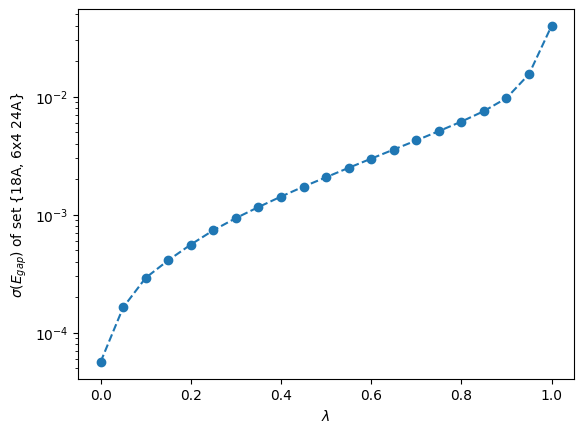

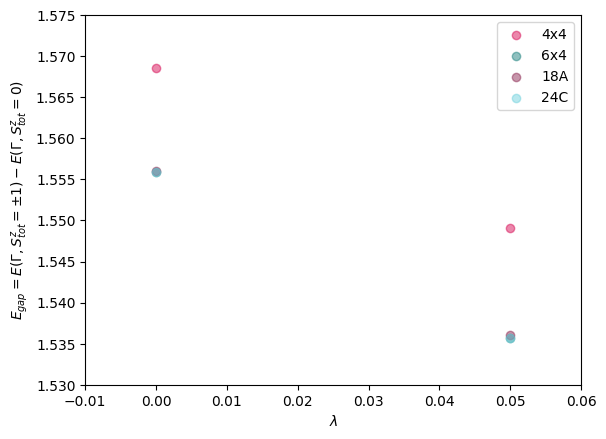

In [ ]:
stdev = np.sqrt(np.var(gaps[1:, :], axis = 0))
plt.semilogy(lamb, stdev, 'o--')

if np.min(stdev) < 3e-6:
    xs = [0., 1.]
    ys = [3e-6, 3e-6]
    plt.semilogy(xs, ys, c = 'gray', ls = '--', label = 'numerical accuracy')
    plt.legend()

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\sigma(E_{gap})$ of set {18A, 6x4 24A}')
plt.show()

for ii in range(gaps.shape[0]):
    plt.scatter(lamb, gaps[ii, :], c = colors[ii], label = labels[ii], alpha = .5)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$E_{gap} = E(\Gamma, S^z_{tot} = \pm 1) - E(\Gamma, S^z_{tot} = 0)$')
plt.xlim([-.01, .06])
plt.ylim([1.53, 1.575])
plt.legend()
plt.show()

In [ ]:
nx, ny = 4, 4
n = nx * ny
steps = 5000

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=1., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 1')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=0., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 0')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')


100%|██████████| 5000/5000 [03:54<00:00, 21.29it/s]


λ = 1
Mean energy: -11.228483178901673
Standard deviation: 2.7422916426943946e-06


100%|██████████| 5000/5000 [05:28<00:00, 15.24it/s]

λ = 0
Mean energy: -9.905236911964417
Standard deviation: 2.9936746642403386e-06


In [ ]:
nx, ny = 4, 4
n = nx * ny
steps = 500

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=0., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 0')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')


100%|██████████| 500/500 [00:32<00:00, 15.41it/s]

λ = 0
Mean energy: -9.905236597061156
Standard deviation: 3.3778250373889357e-06


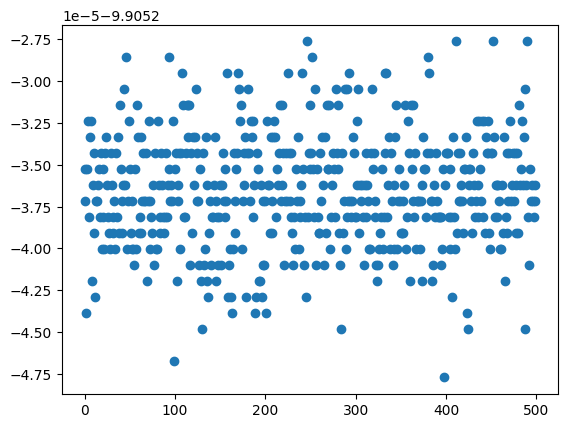

In [ ]:
plt.scatter(range(steps), ens)

2.0


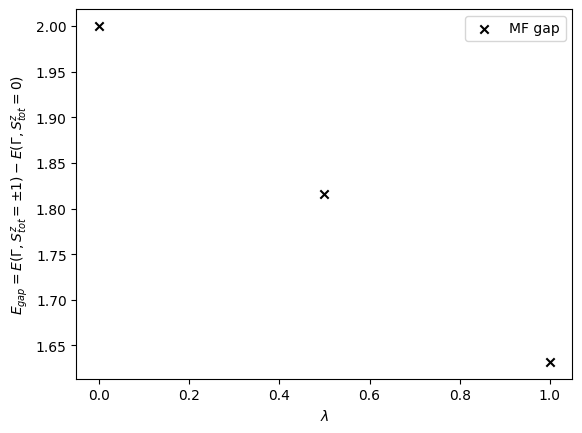

In [4]:
lambda_range = np.linspace(0, 1., 101)
y = 2 * np.sqrt((1. - lamb * 0.046 * 4)**2)
print(y[0])
plt.scatter(lamb, y, c = 'black', marker = 'x', label = 'MF gap')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$E_{gap} = E(\Gamma, S^z_{tot} = \pm 1) - E(\Gamma, S^z_{tot} = 0)$')
#plt.ylim([0, 1.7])
plt.legend()
plt.show()
